# PROJET ESB : Machine learning II

Peut-on identifier des profils-types de districts scolaires en croisant leur niveau d’adoption des bus scolaires électriques, leur situation socio-économique et leur environnement local (pollution, type de région, etc.) ?



Objectif : segmentation des districts pour :

* Repérer les “leaders” ou “retardataires” en matière d’adoption des ESBs.

* Comprendre l’impact des facteurs sociaux et environnementaux sur l’adoption.


In [ ]:
# --------------------------------------------
# 1. Imports des librairies nécessaires
# --------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ESB_adoption_dataset_v8_update_august_2024.xlsx to ESB_adoption_dataset_v8_update_august_2024.xlsx


In [ ]:
# Chargement du fichier Excel
file_path = "ESB_adoption_dataset_v8_update_august_2024.xlsx"
df = pd.read_excel(file_path)

df = pd.read_excel(file_path, sheet_name="1. District-level data")

In [ ]:
# Aperçu des premières lignes
df.head()

,0a. Has committed ESBs?,1a. State,1b. Local Education Agency (LEA) or entity name,1c. LEA ID,1d. Street address 1,1e. Street address 2,1f. City,1g. State,1h. ZIP code,1i. Website,...,5q. WRI Priority Outreach District (POD)?,6a. Has any expression of interest in ESBs?,6b. ARP 2021 waitlist position,6c. DERA school bus rebates 2020 waitlist position,6d. DERA school bus rebates 2021 waitlist position,6e. Applied for ESB funding but not awarded,6f. Member of Climate Mayors Electric Vehicle Purchasing Collaborative?,6g. School district sustainability commitment,6h. District contains Generation180 Solar School?,6i. Participating in Trust for Public Land's Active Community Schoolyard program?
0,no,ALABAMA,Alabama Youth Services,100002,1000 Industrial School Road,NaN,Mt Meigs,AL,36057.0,http://www.dys.alabama.gov/school-district.html,...,False,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,no,ALABAMA,Marshall County,100006,12380 US Highway 431 S,NaN,Guntersville,AL,35976.0,http://www.marshallk12.org,...,False,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,no,ALABAMA,Hoover City,100007,2810 Metropolitan Way,NaN,Hoover,AL,35243.0,http://www.hoovercityschools.net,...,False,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,no,ALABAMA,Madison City,100008,211 Celtic Drive,NaN,Madison,AL,35758.0,http://www.madisoncity.k12.al.us,...,False,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,no,ALABAMA,Al Inst Deaf And Blind,100009,205 E South Street,NaN,Talladega,AL,35160.0,http://www.aidb.org,...,False,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Vérifier le type de colonnes et valeurs manquantes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19516 entries, 0 to 19515
Data columns (total 91 columns):
 #   Column                                                                              Non-Null Count  Dtype  
---  ------                                                                              --------------  -----  
 0   0a. Has committed ESBs?                                                             19516 non-null  object 
 1   1a. State                                                                           19516 non-null  object 
 2   1b. Local Education Agency (LEA) or entity name                                     19516 non-null  object 
 3   1c. LEA ID                                                                          19516 non-null  object 
 4   1d. Street address 1                                                                19507 non-null  object 
 5   1e. Street address 2                                                                360 non-nul

In [ ]:
# Statistiques descriptives uniquement pour les colonnes numériques
df.describe(include='all')  # inclure toutes pour voir aussi les object

,0a. Has committed ESBs?,1a. State,1b. Local Education Agency (LEA) or entity name,1c. LEA ID,1d. Street address 1,1e. Street address 2,1f. City,1g. State,1h. ZIP code,1i. Website,...,5q. WRI Priority Outreach District (POD)?,6a. Has any expression of interest in ESBs?,6b. ARP 2021 waitlist position,6c. DERA school bus rebates 2020 waitlist position,6d. DERA school bus rebates 2021 waitlist position,6e. Applied for ESB funding but not awarded,6f. Member of Climate Mayors Electric Vehicle Purchasing Collaborative?,6g. School district sustainability commitment,6h. District contains Generation180 Solar School?,6i. Participating in Trust for Public Land's Active Community Schoolyard program?
count,19516,19516,19516,19516.0,19507,360,19509,19516,19508.000000,16701,...,19386,19493.000000,28.000000,228.000000,124.0,1769,2631,201,2442,14
unique,2,56,19157,19516.0,18588,297,9461,56,NaN,15884,...,3,NaN,NaN,NaN,124.0,19,6,15,1,1
top,no,CALIFORNIA,Jefferson County,5900141.0,No Address,3rd Floor,PHOENIX,CA,NaN,http://www.successacademies.org,...,False,NaN,NaN,NaN,92.0,2022 CSBP rebate,yes (city),Collaborative for High Performance Schools,yes,yes
freq,17992,2132,5,1.0,27,7,179,2133,NaN,33,...,17848,NaN,NaN,NaN,1.0,1372,1812,94,2442,14
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54071.789471,NaN,...,NaN,0.315139,22.535714,163.973684,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29204.267079,NaN,...,NaN,0.464583,13.068147,97.108002,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,802.000000,NaN,...,NaN,0.000000,1.000000,4.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29942.000000,NaN,...,NaN,0.000000,12.750000,76.750000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57443.500000,NaN,...,NaN,0.000000,21.500000,163.500000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,78031.000000,NaN,...,NaN,1.000000,33.000000,241.250000,NaN,NaN,NaN,NaN,NaN,NaN


On va donc éliminer les colonnes inutiles comme adresse, site web etc et on garde que celles qui sont pertinentes pour notre axe de recherche

In [ ]:
# Affiche toutes les colonnes avec leurs index pour vérifier
for i, col in enumerate(df.columns):
    print(f"{i}: '{col}'")


0: '0a. Has committed ESBs?'
1: '1a. State'
2: '1b. Local Education Agency (LEA) or entity name'
3: '1c. LEA ID'
4: '1d. Street address 1'
5: '1e. Street address 2'
6: '1f. City'
7: '1g. State'
8: '1h. ZIP code'
9: '1i. Website'
10: '1j. Has LEA ID?'
11: '1k. LEA type (number)'
12: '1l. LEA type (name)'
13: '1m. Supervisory union LEA ID'
14: '1n. Locale (full number)'
15: '1o. Locale broad type (number)'
16: '1p. Locale broad type (name)'
17: '1q. Census Region'
18: '1r. Census Division'
19: '1s. Latitude'
20: '1t. Longitude '
21: '2a. Total number of buses'
22: '2b. Contractor used for some or all of buses?'
23: '3a. Number of ESBs committed '
24: '3b. Number of delivered or operating ESBs'
25: '3c. Number of ESBs awarded'
26: '3d. Number of ESBs ordered'
27: '3e. Number of ESBs delivered'
28: '3f. Number of ESBs operating'
29: '3g. Number of batches'
30: '3h. Size of batch 1'
31: '3h. Size of batch 2'
32: '3h. Size of batch 3'
33: '3h. Size of batch 4'
34: '3h. Size of batch 5'
35: '

## L'adoption des ESBs

In [ ]:
selected_columns = [
    # Adoption des ESBs
    "3a. Number of ESBs committed ",
    "3b. Number of delivered or operating ESBs",
    "3c. Number of ESBs awarded",
    "3d. Number of ESBs ordered",
    "3e. Number of ESBs delivered",
    "3f. Number of ESBs operating",
    "3i. Percent of fleet that is electric",
    "2a. Total number of buses",

    # Socio-économiques
    "4b. Number of students in district",
    "4c. Number of schools in district",
    "4d. Percentage of schools in district that are Title I schoolwide eligible",
    "4e. Percentage of students in district eligible for free or reduced price lunch",
    "4f. Median household income",
    "4g. Percent of population below the poverty level",

    # Démographiques & environnementales
    "4h. Percent one race: White ",
    "4j. Percent one race: Black or African American ",
    "4l. Percent one race: American Indian and Alaska Native ",
    "4n. Percent one race: Asian ",
    "4p. Percent one race: Native Hawaiian and Other Pacific Islander ",
    "4r. Percent one race: some other race ",
    "4t. Percent two or more races",
    "4u. Percent Hispanic or Latino (of any race) ",

    "5f. PM2.5 concentration",
    "5h. Ozone concentration",
    "5l. Average rate of asthma among adults aged 18 and older"
]


In [ ]:
df_selected = df[selected_columns].copy()
df_selected.head()

,3a. Number of ESBs committed,3b. Number of delivered or operating ESBs,3c. Number of ESBs awarded,3d. Number of ESBs ordered,3e. Number of ESBs delivered,3f. Number of ESBs operating,3i. Percent of fleet that is electric,2a. Total number of buses,4b. Number of students in district,4c. Number of schools in district,...,4j. Percent one race: Black or African American,4l. Percent one race: American Indian and Alaska Native,4n. Percent one race: Asian,4p. Percent one race: Native Hawaiian and Other Pacific Islander,4r. Percent one race: some other race,4t. Percent two or more races,4u. Percent Hispanic or Latino (of any race),5f. PM2.5 concentration,5h. Ozone concentration,5l. Average rate of asthma among adults aged 18 and older
0,0,0,0,0,0,0,0.0,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,0,0,0,0,0,0.0,112.0,5951.0,15.0,...,0.011,0.007,0.002,0.001,0.022,0.036,0.118,8.733428,60.656726,0.099903
2,0,0,0,0,0,0,0.0,189.0,13557.0,18.0,...,0.194,0.002,0.054,0.000,0.019,0.029,0.052,10.200577,66.566885,0.084228
3,0,0,0,0,0,0,0.0,109.0,12473.0,11.0,...,0.140,0.004,0.067,0.000,0.011,0.042,0.066,8.456033,60.192694,0.089050
4,0,0,0,0,0,0,0.0,NaN,NaN,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Nettoyage des valeurs manquantes

In [ ]:
df_selected.isnull().sum().sort_values(ascending=False)

,0
2a. Total number of buses,9786
4f. Median household income,6502
5l. Average rate of asthma among adults aged 18 and older,6450
4g. Percent of population below the poverty level,6443
4r. Percent one race: some other race,6440
4j. Percent one race: Black or African American,6436
4h. Percent one race: White,6436
4p. Percent one race: Native Hawaiian and Other Pacific Islander,6436
4l. Percent one race: American Indian and Alaska Native,6436
4t. Percent two or more races,6436


## 1. Colonnes avec valeurs manquantes à 0 = Absence réelle
* Ces valeurs sont des quantités concrètes. S'il manque des infos, il n'est pas prudent de supposer 0. On remplit dnc avec la médiane

## 2. Colonnes socio-démographiques / environnementales
* Ces données sont des indicateurs continus où on veut garder les valeurs dans une plage réaliste.
Solution cohérente avec la standardisation : remplir par la moyenne.

## 3. Colonnes ethno-raciales (%)
* Ces colonnes doivent somme toute rester proportionnelles (pas des valeurs arbitraires).
Ici, la moyenne est aussi acceptable (elle conserve mieux la distribution).

Supprimer les lignes encore incomplètes

In [ ]:
from sklearn.impute import SimpleImputer

# --- 2. Imputation par médiane (quantitatifs bruts)
median_impute_cols = [
    "2a. Total number of buses", "3i. Percent of fleet that is electric",
    "4b. Number of students in district", "4c. Number of schools in district",
    "4d. Percentage of schools in district that are Title I schoolwide eligible",
    "4e. Percentage of students in district eligible for free or reduced price lunch"
]

median_imputer = SimpleImputer(strategy="median")
df_selected[median_impute_cols] = median_imputer.fit_transform(df_selected[median_impute_cols])

# --- 3. Imputation par moyenne (ratios, proportions)
mean_impute_cols = [
    "4f. Median household income", "4g. Percent of population below the poverty level",
    "5f. PM2.5 concentration", "5h. Ozone concentration", "5l. Average rate of asthma among adults aged 18 and older",
    "4h. Percent one race: White ", "4j. Percent one race: Black or African American ",
    "4l. Percent one race: American Indian and Alaska Native ", "4n. Percent one race: Asian ",
    "4p. Percent one race: Native Hawaiian and Other Pacific Islander ",
    "4r. Percent one race: some other race ", "4t. Percent two or more races",
    "4u. Percent Hispanic or Latino (of any race) "
]

mean_imputer = SimpleImputer(strategy="mean")
df_selected[mean_impute_cols] = mean_imputer.fit_transform(df_selected[mean_impute_cols])

# --- 4. Suppression des éventuelles lignes encore incomplètes
df_selected = df_selected.dropna()

# --- 5. Standardisation (z-score) pour machine learning
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_selected), columns=df_selected.columns)


In [ ]:
# --- 6. Aperçu final
print("Aperçu des données standardisées :")
print(df_scaled.head())

Aperçu des données standardisées :
   3a. Number of ESBs committed   3b. Number of delivered or operating ESBs  \
0                      -0.124267                                  -0.069975   
1                      -0.124267                                  -0.069975   
2                      -0.124267                                  -0.069975   
3                      -0.124267                                  -0.069975   
4                      -0.124267                                  -0.069975   

   3c. Number of ESBs awarded  3d. Number of ESBs ordered  \
0                   -0.124763                   -0.053534   
1                   -0.124763                   -0.053534   
2                   -0.124763                   -0.053534   
3                   -0.124763                   -0.053534   
4                   -0.124763                   -0.053534   

   3e. Number of ESBs delivered  3f. Number of ESBs operating  \
0                     -0.018565                     -0.068

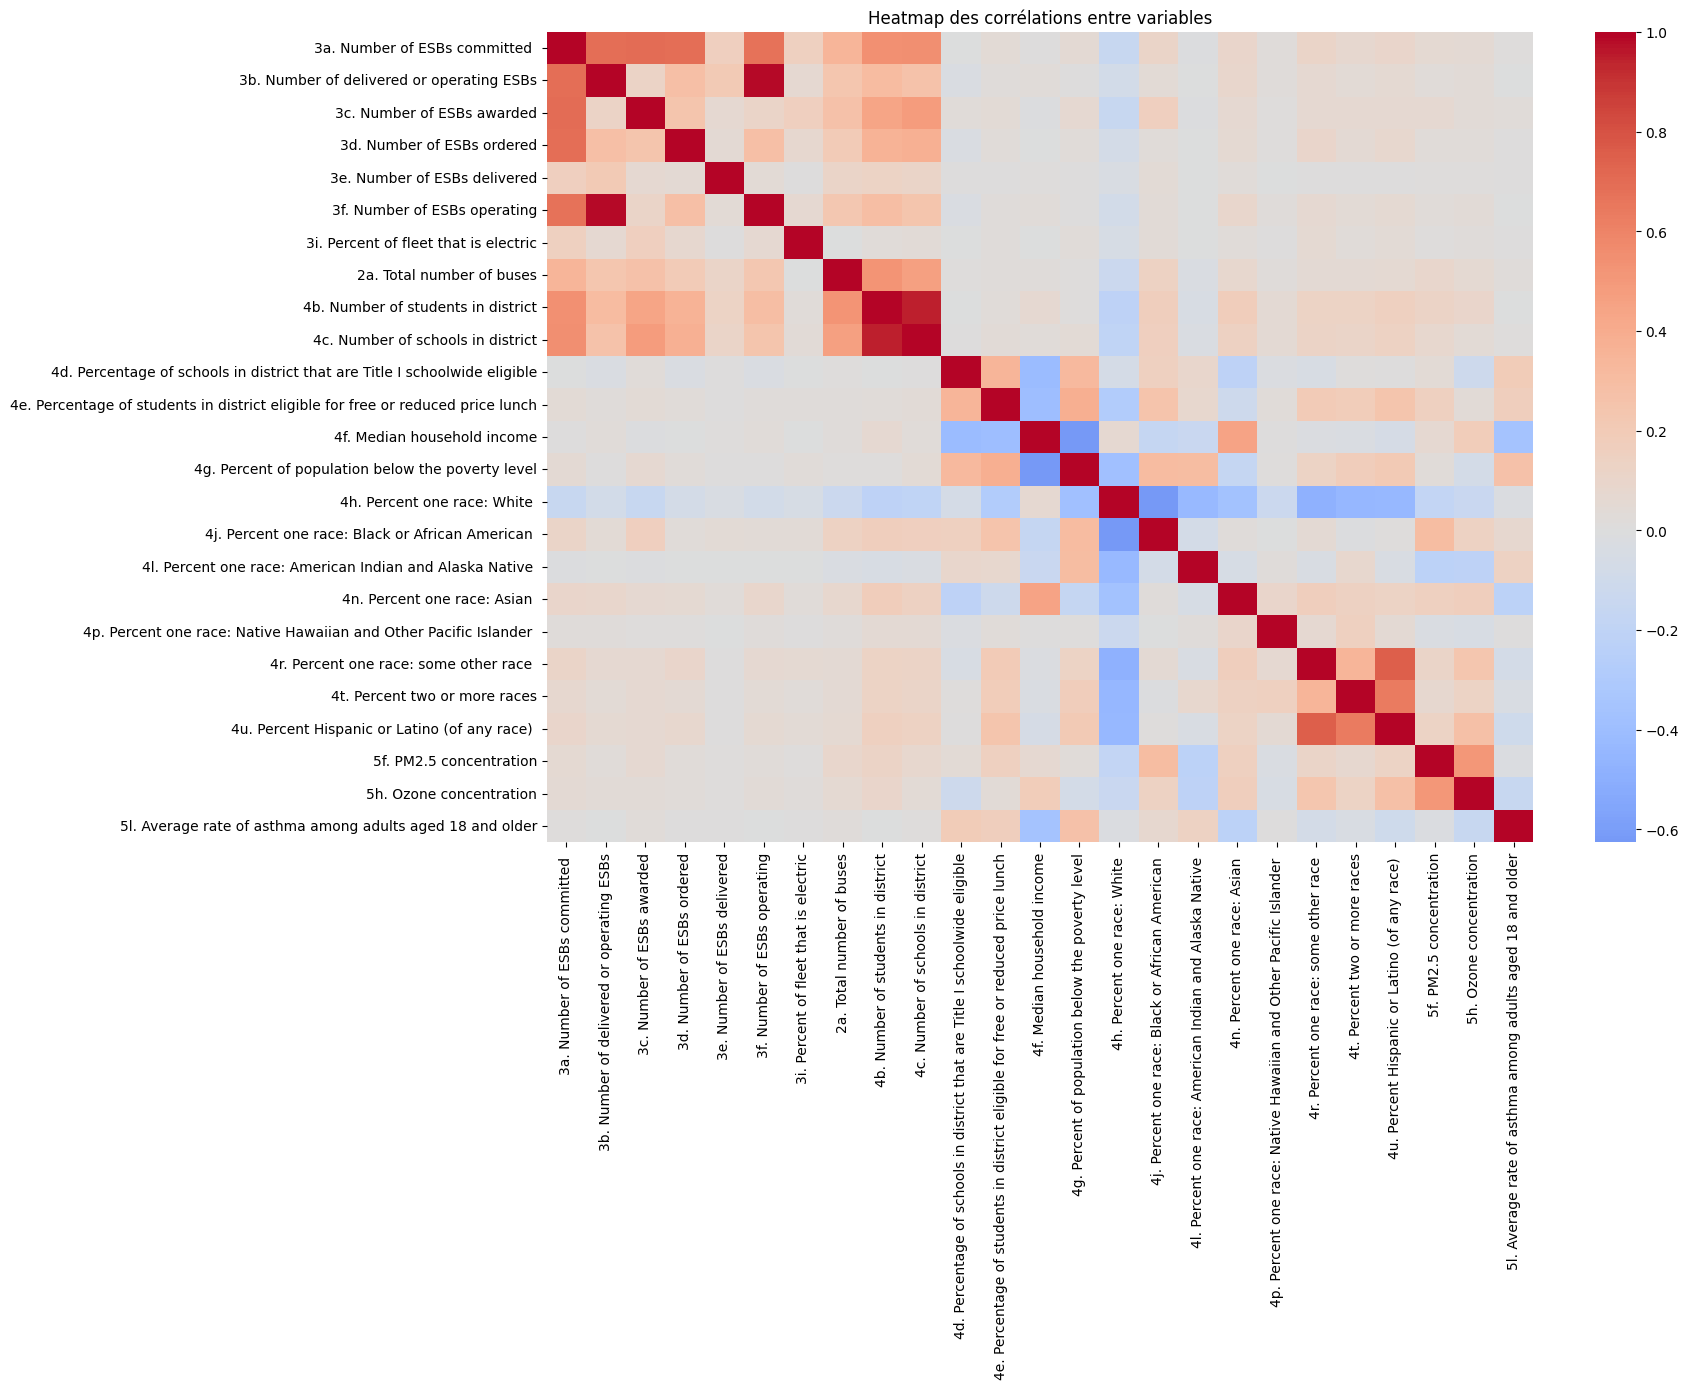

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 14))
sns.heatmap(df_scaled.corr(), cmap='coolwarm', center=0, annot=False)
plt.title("Heatmap des corrélations entre variables")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np

# Calcul de la matrice de corrélation absolue
corr_matrix = df_scaled.corr().abs()

# Conserver seulement la moitié supérieure de la matrice
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identifier les colonnes à supprimer (corrélation > 0.70)
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.70)]

# Affichage des colonnes supprimées
print("Colonnes supprimées car corrélées > 0.70 :", to_drop)

# Suppression des colonnes du DataFrame
df_filtered = df_scaled.drop(columns=to_drop)


Colonnes supprimées car corrélées > 0.70 : ['3c. Number of ESBs awarded', '3f. Number of ESBs operating', '4c. Number of schools in district', '4u. Percent Hispanic or Latino (of any race) ']


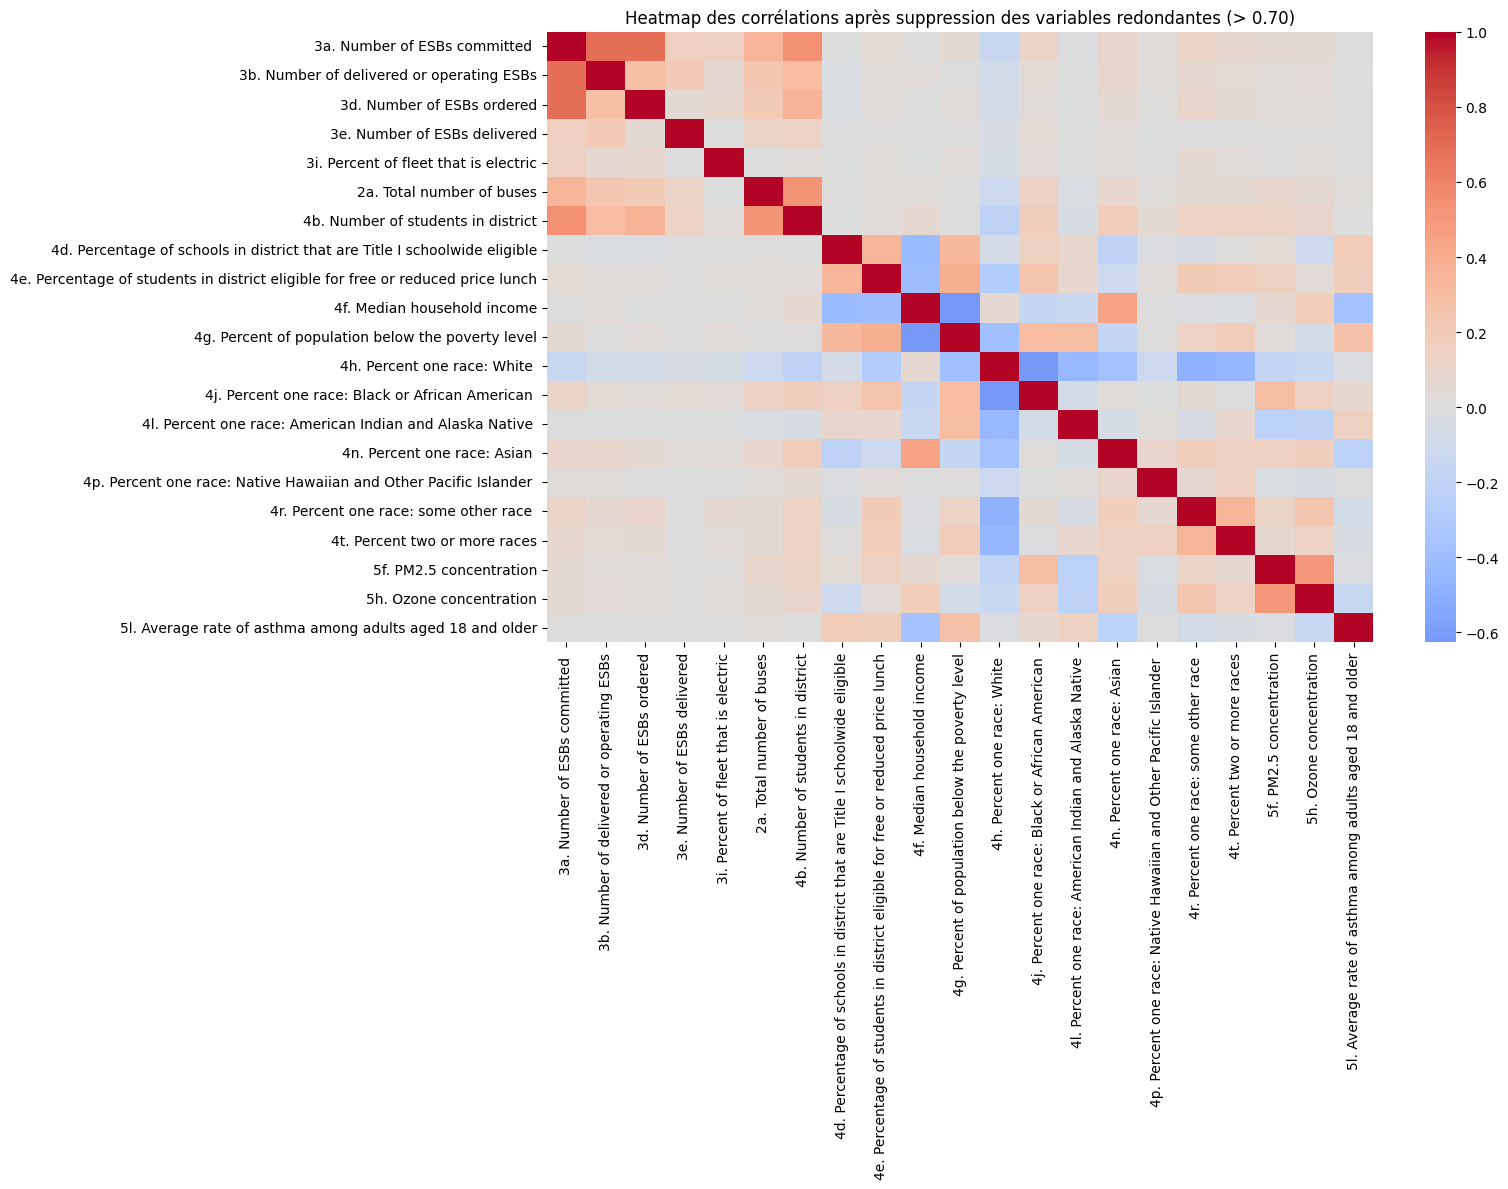


Colonnes restantes après filtrage :
['3a. Number of ESBs committed ', '3b. Number of delivered or operating ESBs', '3d. Number of ESBs ordered', '3e. Number of ESBs delivered', '3i. Percent of fleet that is electric', '2a. Total number of buses', '4b. Number of students in district', '4d. Percentage of schools in district that are Title I schoolwide eligible', '4e. Percentage of students in district eligible for free or reduced price lunch', '4f. Median household income', '4g. Percent of population below the poverty level', '4h. Percent one race: White ', '4j. Percent one race: Black or African American ', '4l. Percent one race: American Indian and Alaska Native ', '4n. Percent one race: Asian ', '4p. Percent one race: Native Hawaiian and Other Pacific Islander ', '4r. Percent one race: some other race ', '4t. Percent two or more races', '5f. PM2.5 concentration', '5h. Ozone concentration', '5l. Average rate of asthma among adults aged 18 and older']


In [ ]:
import matplotlib.pyplot as plt
# Recalculer la matrice de corrélation avec les colonnes restantes
corr_matrix_filtered = df_filtered.corr()

# Afficher la nouvelle heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix_filtered, cmap='coolwarm', center=0, annot=False)
plt.title("Heatmap des corrélations après suppression des variables redondantes (> 0.70)")
plt.tight_layout()
plt.show()

# Afficher les nouvelles colonnes restantes
print("\nColonnes restantes après filtrage :")
print(df_filtered.columns.tolist())

# KMEANS

# Réduction de Dimension 3 méthodes: KPCA et UMAP et TSNE


Réduction de dimension avec Kernel PCA (KPCA)...


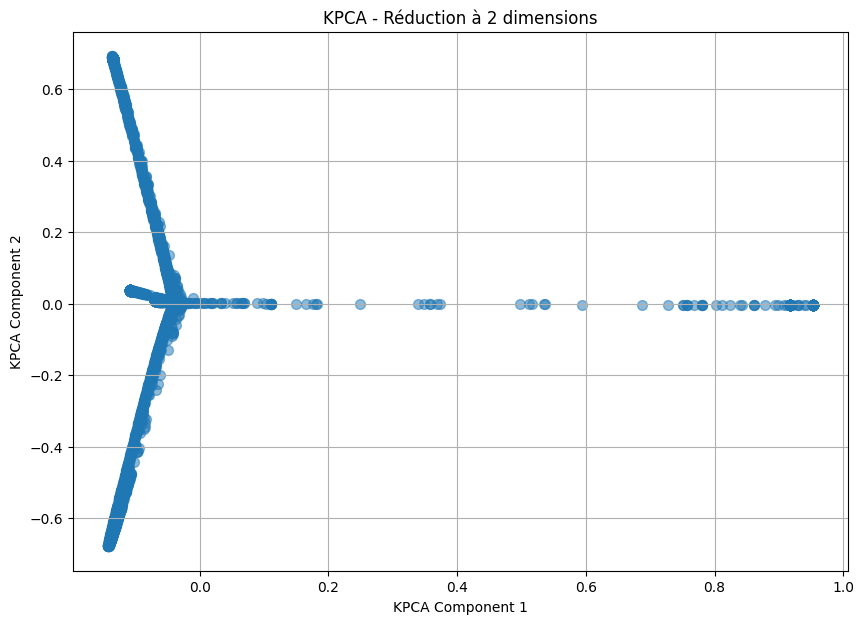

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt


from sklearn.decomposition import KernelPCA
from umap import UMAP
from sklearn.manifold import TSNE

# Sélection des données pour la réduction de dimension
X = df_filtered.copy()

# 1. Réduction de dimension avec Kernel PCA (KPCA)
print("\nRéduction de dimension avec Kernel PCA (KPCA)...")
kpca = KernelPCA(n_components=2, kernel='rbf', fit_inverse_transform=True, gamma=10)
X_kpca = kpca.fit_transform(X)

# Création d'un DataFrame pour les résultats KPCA
df_kpca = pd.DataFrame(data=X_kpca, columns=['KPCA1', 'KPCA2'])
df_kpca.head()

# Visualisation KPCA
plt.figure(figsize=(10, 7))
plt.scatter(df_kpca['KPCA1'], df_kpca['KPCA2'], s=50, alpha=0.5)
plt.title('KPCA - Réduction à 2 dimensions')
plt.xlabel('KPCA Component 1')
plt.ylabel('KPCA Component 2')
plt.grid(True)
plt.show()



Réduction de dimension avec UMAP...


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


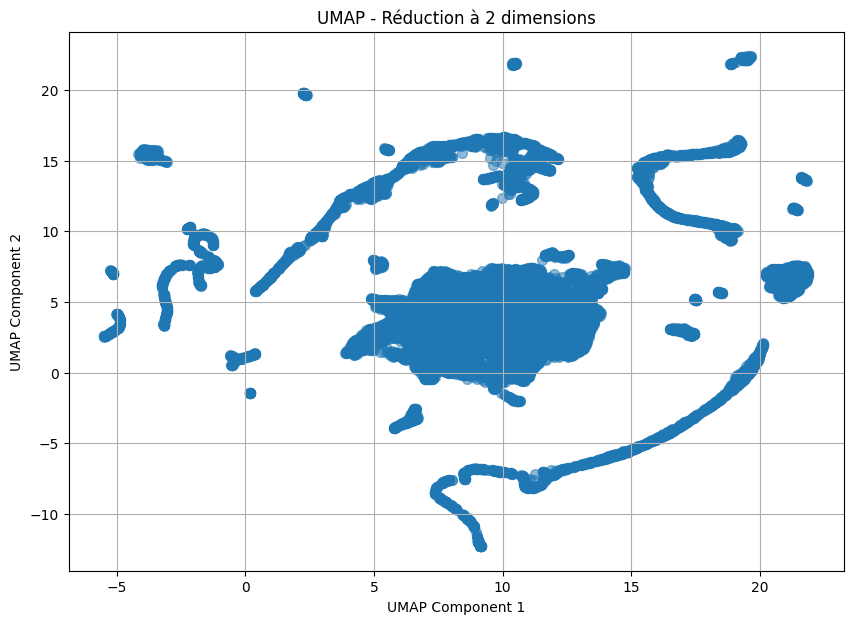

In [ ]:

# 2. Réduction de dimension avec UMAP
print("\nRéduction de dimension avec UMAP...")
umap_reducer = UMAP(n_components=2, random_state=42,n_neighbors=15, min_dist=0.1)
X_umap = umap_reducer.fit_transform(X)

# Création d'un DataFrame pour les résultats UMAP
df_umap = pd.DataFrame(data=X_umap, columns=['UMAP1', 'UMAP2'])
df_umap.head()

# Visualisation UMAP
plt.figure(figsize=(10, 7))
plt.scatter(df_umap['UMAP1'], df_umap['UMAP2'], s=50, alpha=0.5)
plt.title('UMAP - Réduction à 2 dimensions')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.grid(True)
plt.show()



Réduction de dimension avec t-SNE...


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


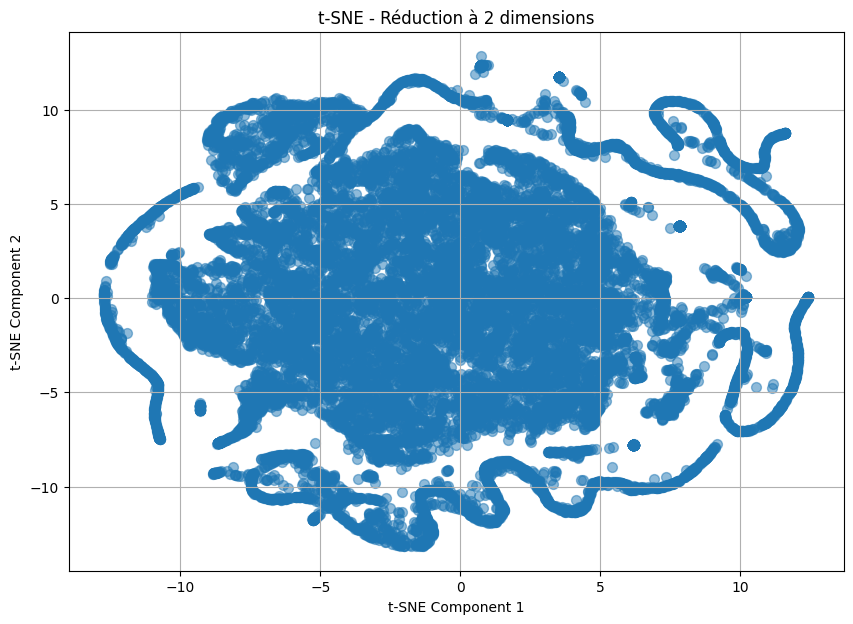

In [ ]:
# 3. Réduction de dimension avec t-SNE
print("\nRéduction de dimension avec t-SNE...")
# perplexity et n_iter sont des paramètres importants pour t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=300)
X_tsne = tsne.fit_transform(X)

# Création d'un DataFrame pour les résultats t-SNE
df_tsne = pd.DataFrame(data=X_tsne, columns=['TSNE1', 'TSNE2'])
df_tsne.head()

# Visualisation t-SNE
plt.figure(figsize=(10, 7))
plt.scatter(df_tsne['TSNE1'], df_tsne['TSNE2'], s=50, alpha=0.5)
plt.title('t-SNE - Réduction à 2 dimensions')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True)
plt.show()

# Silouhette score et Elobow Method pour déterminer le bon nombre de cluster

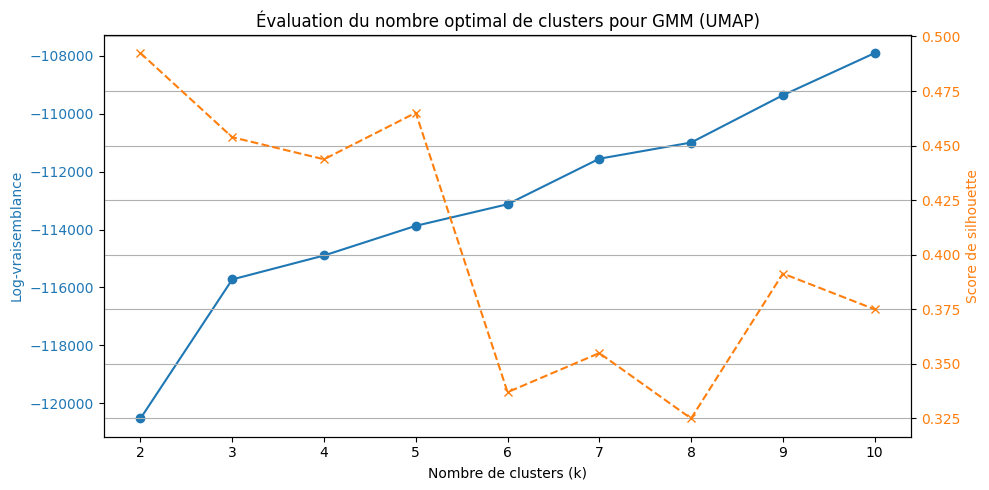

In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

X_umap = df_umap[['UMAP1', 'UMAP2']].values

# Tester plusieurs valeurs de k
k_range = range(2, 11)
log_likelihood = []
silhouette_scores = []

for k in k_range:
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gmm.fit(X_umap)
    labels = gmm.predict(X_umap)

    log_likelihood.append(gmm.score(X_umap) * len(X_umap))  # log-vraisemblance totale
    silhouette_scores.append(silhouette_score(X_umap, labels))

# Affichage combiné
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel("Nombre de clusters (k)")
ax1.set_ylabel("Log-vraisemblance", color=color)
ax1.plot(k_range, log_likelihood, marker='o', color=color, label='Log-likelihood')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_title("Évaluation du nombre optimal de clusters pour GMM (UMAP)")

# Deuxième axe : silhouette
ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel("Score de silhouette", color=color)
ax2.plot(k_range, silhouette_scores, marker='x', linestyle='--', color=color, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.grid(True)
plt.show()


# Clustering avec GMM sur UMAP avec k=3

In [ ]:
from sklearn.mixture import GaussianMixture

# Forcer le bon modèle GMM compatible pour affichage 2D
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(X_umap)

# Prédictions
df_umap['gmm_cluster'] = gmm.predict(X_umap)
gmm_proba = gmm.predict_proba(X_umap)


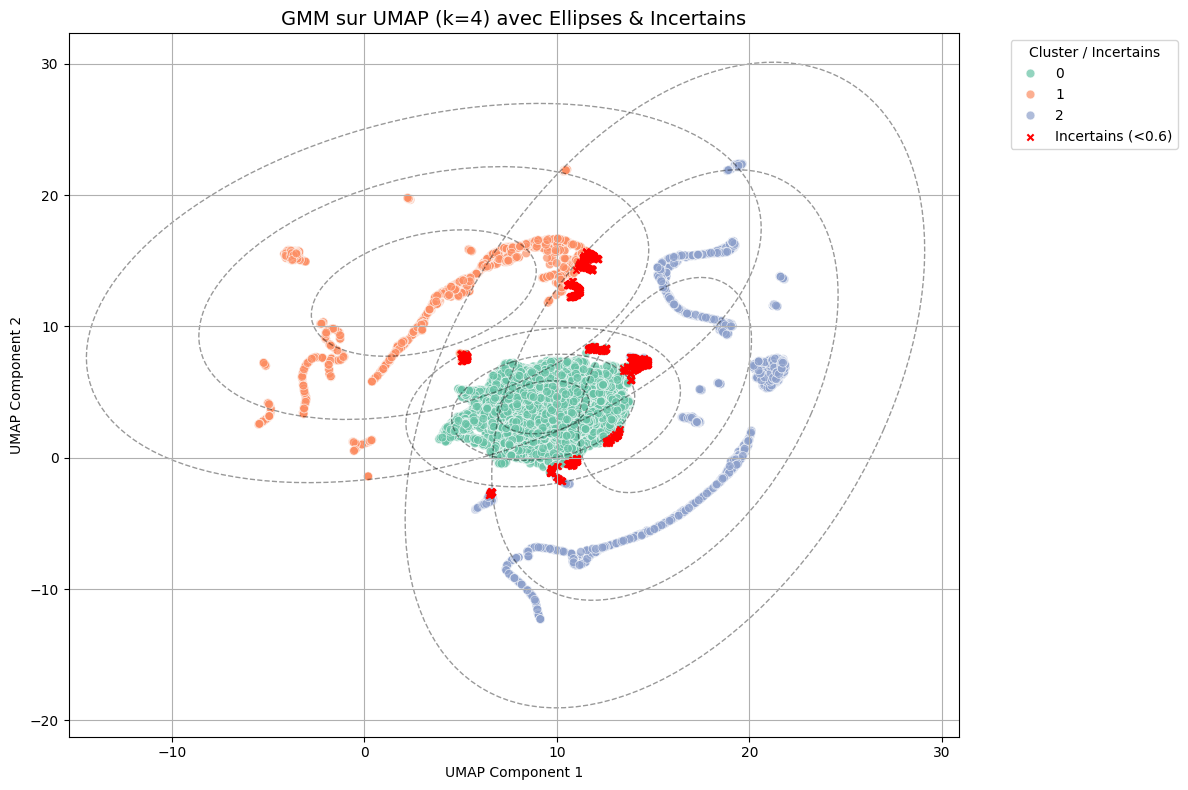

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=df_umap, x='UMAP1', y='UMAP2', hue='gmm_cluster', palette='Set2', s=40, alpha=0.7, ax=ax)

# Ajout des ellipses 2D
for i in range(gmm.n_components):
    mean = gmm.means_[i]
    cov = gmm.covariances_[i]
    if cov.shape == (2, 2):
        draw_ellipse(mean, cov, ax, edgecolor='black', linestyle='--', linewidth=1, alpha=0.4)


# Incertains
df_umap['max_proba'] = gmm_proba.max(axis=1)
incertains = df_umap[df_umap['max_proba'] < 0.7]
ax.scatter(incertains['UMAP1'], incertains['UMAP2'], color='red', s=20, marker='x', label='Incertains (<0.6)')

plt.title("GMM sur UMAP (k=4) avec Ellipses & Incertains", fontsize=14)
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.grid(True)
plt.legend(title="Cluster / Incertains", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


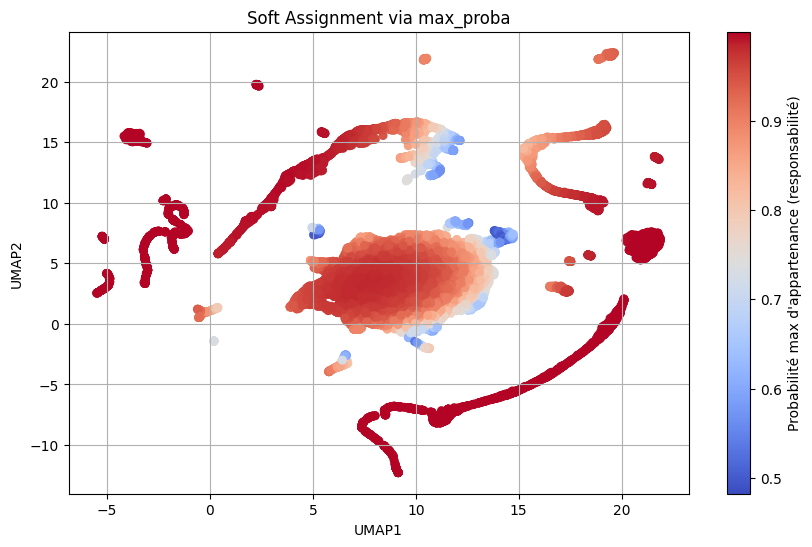

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df_umap['UMAP1'], df_umap['UMAP2'],
                     c=df_umap['max_proba'], cmap='coolwarm', s=30)
plt.colorbar(scatter, ax=ax, label="Probabilité max d'appartenance (responsabilité)")
plt.title("Soft Assignment via max_proba")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.grid(True)
plt.show()


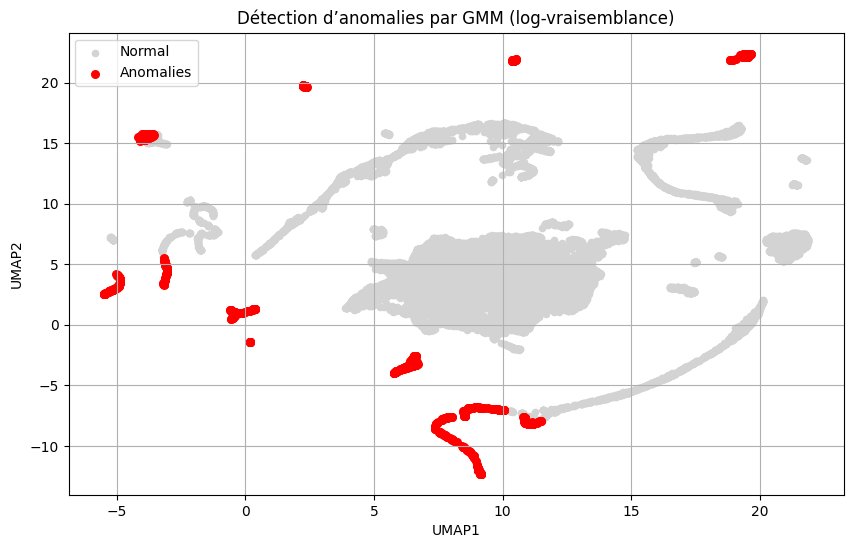

In [ ]:
log_probs = gmm.score_samples(X_umap)
df_umap['log_likelihood'] = log_probs

thresh = np.percentile(log_probs, 8)  # Seuil des 8% les plus faibles
anomalies = df_umap[df_umap['log_likelihood'] < thresh]

plt.figure(figsize=(10, 6))
plt.scatter(df_umap['UMAP1'], df_umap['UMAP2'], c='lightgray', s=20, label='Normal')
plt.scatter(anomalies['UMAP1'], anomalies['UMAP2'], c='red', s=30, label='Anomalies')
plt.title("Détection d’anomalies par GMM (log-vraisemblance)")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.legend()
plt.grid(True)
plt.show()


## Point le plus anormale

In [ ]:
# 1. Identifier le point le plus anormal (log-likelihood minimum)
worst_anomaly_idx = df_umap['log_likelihood'].idxmin()

# 2. Afficher les valeurs originales de ce point dans df_features
print(f"--- Observation la plus anormale (index {worst_anomaly_idx}) ---")
display(df_filtered.loc[worst_anomaly_idx].to_frame().T)


--- Observation la plus anormale (index 4744) ---


,3a. Number of ESBs committed,3b. Number of delivered or operating ESBs,3d. Number of ESBs ordered,3e. Number of ESBs delivered,3i. Percent of fleet that is electric,2a. Total number of buses,4b. Number of students in district,4d. Percentage of schools in district that are Title I schoolwide eligible,4e. Percentage of students in district eligible for free or reduced price lunch,4f. Median household income,4g. Percent of population below the poverty level,4h. Percent one race: White,4j. Percent one race: Black or African American,4l. Percent one race: American Indian and Alaska Native,4n. Percent one race: Asian,4p. Percent one race: Native Hawaiian and Other Pacific Islander,4r. Percent one race: some other race,4t. Percent two or more races,5f. PM2.5 concentration,5h. Ozone concentration,5l. Average rate of asthma among adults aged 18 and older
4744,-0.124267,-0.069975,-0.053534,-0.018565,-0.075165,-0.266247,-0.19761,-1.226054,0.013872,-6.424103e-16,0.0,-7.639313e-16,7.453682e-17,0.0,0.0,-2.384686e-17,7.211917e-17,-1.890687e-16,0.0,-3.988924e-15,0.0


In [ ]:
import pandas as pd
from IPython.display import display

# Colonnes à conserver
selected_columns = [
     '3a. Number of ESBs committed ',
     '3b. Number of delivered or operating ESBs',
     '3d. Number of ESBs ordered',
     '3e. Number of ESBs delivered',
    # '3i. Percent of fleet that is electric',
    '2a. Total number of buses',
    '4b. Number of students in district',
    # '4d. Percentage of schools in district that are Title I schoolwide eligible',
    # '4e. Percentage of students in district eligible for free or reduced price lunch',
    # '4f. Median household income',
    # # '4g. Percent of population below the poverty level',
    # # '4h. Percent one race: White ',
    # # '4j. Percent one race: Black or African American ',
    # # '4l. Percent one race: American Indian and Alaska Native ',
    # # '4n. Percent one race: Asian ',
    # # '4p. Percent one race: Native Hawaiian and Other Pacific Islander ',
    # # '4r. Percent one race: some other race ',
    # # '4t. Percent two or more races',
    # '5f. PM2.5 concentration',
    # '5h. Ozone concentration',
    # '5l. Average rate of asthma among adults aged 18 and older'
]

# Nombre d'anomalies à afficher
nb_anomalies = 40
top_anomalies_idx = df_umap.nsmallest(nb_anomalies, 'log_likelihood').index

# Extraire les lignes anormales depuis df_filtered
anomalies_table = df_original.loc[top_anomalies_idx, selected_columns]

# Afficher sous forme de tableau unique
display(anomalies_table)


,3a. Number of ESBs committed,3b. Number of delivered or operating ESBs,3d. Number of ESBs ordered,3e. Number of ESBs delivered,2a. Total number of buses,4b. Number of students in district
4744,0,0,0,0,1.0,NaN
7154,0,0,0,0,1.0,NaN
4551,0,0,0,0,1.0,NaN
4722,0,0,0,0,2.0,NaN
7104,0,0,0,0,2.0,NaN
4748,0,0,0,0,5.0,NaN
4557,0,0,0,0,9.0,NaN
7201,0,0,0,0,3.0,NaN
7155,0,0,0,0,5.0,NaN
7199,0,0,0,0,4.0,NaN


# Définition des Clusters via calcul de Moyenne

In [ ]:
# Fusionner les labels GMM avec les features d'origine (X)
df_cluster_summary = X.copy()
df_cluster_summary['Cluster'] = df_umap['gmm_cluster']

# Calcul des moyennes par cluster
cluster_means = df_cluster_summary.groupby('Cluster').mean().round(2)

# Affichage
import pandas as pd
pd.set_option('display.max_columns', None)
display(cluster_means)


,3a. Number of ESBs committed,3b. Number of delivered or operating ESBs,3d. Number of ESBs ordered,3e. Number of ESBs delivered,3i. Percent of fleet that is electric,2a. Total number of buses,4b. Number of students in district,4d. Percentage of schools in district that are Title I schoolwide eligible,4e. Percentage of students in district eligible for free or reduced price lunch,4f. Median household income,4g. Percent of population below the poverty level,4h. Percent one race: White,4j. Percent one race: Black or African American,4l. Percent one race: American Indian and Alaska Native,4n. Percent one race: Asian,4p. Percent one race: Native Hawaiian and Other Pacific Islander,4r. Percent one race: some other race,4t. Percent two or more races,5f. PM2.5 concentration,5h. Ozone concentration,5l. Average rate of asthma among adults aged 18 and older
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.07,0.04,0.03,0.01,0.04,0.07,0.12,0.05,0.01,-0.04,-0.03,0.07,0.01,-0.13,-0.03,0.01,0.00,-0.01,0.03,0.02,0.27
1,-0.11,-0.06,-0.05,-0.02,-0.07,-0.12,-0.21,0.75,0.30,-0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00
2,-0.10,-0.06,-0.04,-0.01,-0.05,-0.09,-0.17,-0.79,-0.30,0.12,0.08,-0.19,-0.02,0.37,0.10,-0.02,-0.01,0.02,-0.10,-0.07,-0.80


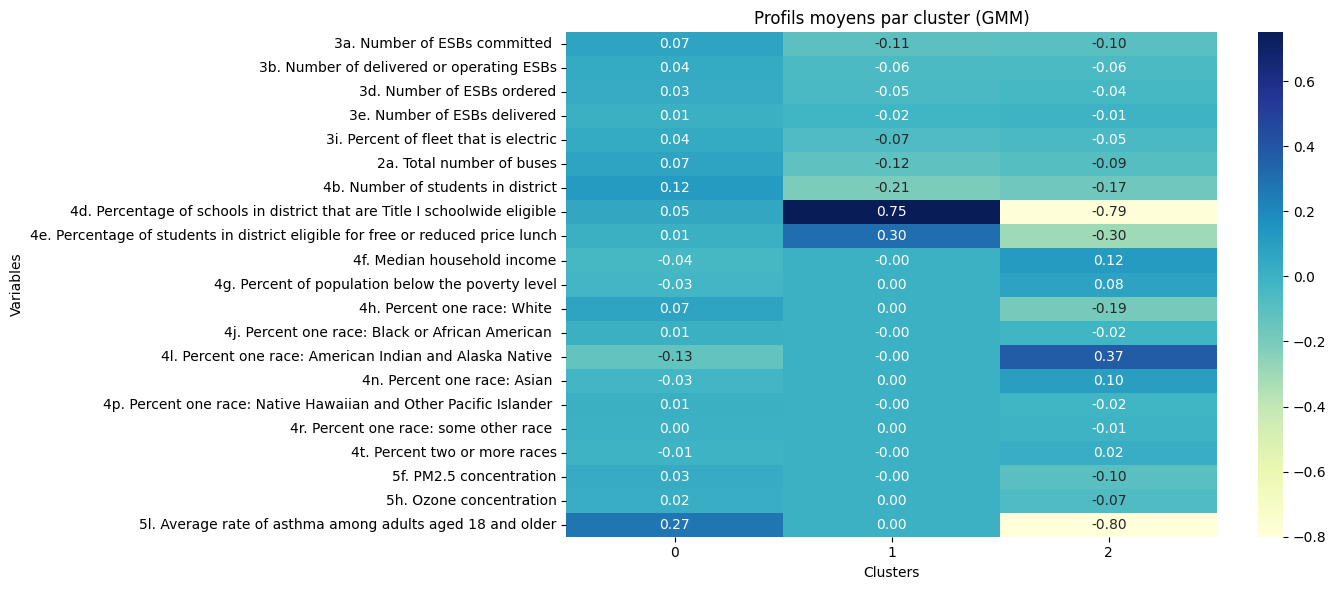

In [ ]:
plt.figure(figsize=(14, 6))
sns.heatmap(cluster_means.T, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Profils moyens par cluster (GMM)")
plt.ylabel("Variables")
plt.xlabel("Clusters")
plt.tight_layout()
plt.show()


## Objectif de l’analyse

L’objectif est de **segmenter les districts scolaires** selon leurs caractéristiques sociales, environnementales et leurs engagements dans la transition vers des bus scolaires électriques (ESBs).  
Cela vise à **identifier des profils-types**, mettre en évidence des **inégalités**, et repérer des **zones potentiellement oubliées** dans la politique d’électrification des bus ESB

---

## Comment on lit la Heatmap?

Chaque cellule représente la **valeur moyenne centrée-réduite** d’une variable pour un cluster issu du GMM (appliqué sur l’espace UMAP).  
- Valeur ≈ 0 → dans la moyenne  
- Valeur > 0 → au-dessus de la moyenne  
- Valeur < 0 → en dessous de la moyenne  

---

## Analyse des clusters observés

### Cluster 0 – Districts en transition, vulnérabilités environnementales

- Moyennement engagés sur les ESBs (`3a` à `3i` légèrement positifs)
- Population étudiante modérément élevée
- Taux d’asthme élevé (+0.27) → exposition environnementale
- Présence notable de populations minoritaires (ex : `American Indian`)
- Revenu légèrement en dessous de la moyenne
- ➤ Districts **en cours d’effort**, mais encore **fragiles sur le plan environnemental et social**

---

### Cluster 1 – Districts très défavorisés, peu électrifiés

- Très forts taux de pauvreté éducative :
  -  (+0.75)
  - Éligibilité repas gratuits (+0.30)
- Très peu d’engagement ESB
- Peu d’élèves, peu de bus → zones rurales ou sous-financées
- Aucun groupe racial dominant → profil démographiquement neutre
- ➤ **Vulnérables mais invisibles** : pas ciblés malgré des besoins évidents

---

### Cluster 2 – Districts riches, déjà en avance

- Très hauts revenus (+0.12), faible pauvreté, forte part de blancs (-0.19)
- Sous-représentation des élèves défavorisés (`-0.79`)
- Faible asthme (`-0.80`) → bonnes conditions sanitaires
- Forte représentation de populations asiatiques (+0.37)
- Engagement modéré sur les ESBs mais conditions favorables
- ➤ **Déjà bien desservis**, électrification en cours, **pas la priorité immédiate**

---

## Comment détecter les outliers?

Des points détectés comme anomalies via :
- Faible log-vraisemblance
- Faible probabilité d’appartenance à un cluster

Ils représentent :
- Soit des **cas extrêmes réels** (ex. districts avec 1 seul bus)
- Soit des **données incomplètes ou corrompues**
- ➤ À investiguer : **certaines zones critiques peuvent être exclues à tort des analyses classiques**

---

## Limites et remarques

- **Peu de personnes d'ethnies blanches dans le cluster riche** : peut révéler un **biais dans les données** ou une homogénéité masquant les effets
- Forte **corrélation entre pauvreté ↔ environnement ↔ santé** observable
- UMAP + GMM est **puissant mais sensible aux outliers**

---

## Conclusion

**Problématique :**  
*Quels types de districts adoptent ou non les ESBs, et comment cela se recoupe-t-il avec les inégalités sociales et environnementales ?*

**Réponse :**

Trois profils émergent :
-  **Régions favorisées**, bien électrifiées mais avec peu d'urgence sanitaire
- **Régions vulnérables**, ignorées malgré des besoins évidents
- **Régions en transition**, exposées aux risques mais engagées

➤ **Les politiques actuelles semblent favoriser ceux qui en ont le moins besoin.**  
Un redéploiement des ressources basé sur cette segmentation serait **plus équitable** et **plus impactant**.

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!jupyter nbconvert --to html '/content/Machine_Learning_Final.ipynb'
!cp '/content/Machine_Learning_Final.html' '/content/drive/MyDrive/Machine_Learning_Final.html'


[NbConvertApp] WARNING | pattern '/content/Machine_Learning_Final.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes